# Shipment Risk Analyser

I'm estimating **P(incident in next 6 hours)** for cold-chain shipments. At each decision time I only use telemetry the platform has **already received**, not sensor clock time, not future labels.

## What I'm demonstrating

| Phase | Business question | Model updates? |
|-------|-------------------|----------------|
| **A: Train** | What patterns predict incidents on historical shipments? | Yes → `artifact/model.joblib` |
| **B: Score** | Given a live stream, what is risk right now? | No → load artifact, ingest, predict |

Phase B uses five scripted streams I never trained on: stable chain, gradual warming, late correction, door events, and delayed ingest.

```bash
jupyter notebook optional/notebooks/demo_shipment_walkthrough.ipynb
cd optional && streamlit run app.py   # same flow in Streamlit
```


In [8]:
import importlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

OPTIONAL_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() / "optional"
ROOT = OPTIONAL_DIR.parent
sys.path[:0] = [str(ROOT / "src"), str(OPTIONAL_DIR)]

# Define paths here so a stale Jupyter kernel cannot break imports.
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifact"

from dispatch_risk.solution import RiskEngine, build_training_rows, train

import demo_helpers

importlib.reload(demo_helpers)
from demo_helpers import (
    WALKTHROUGH_DIR,
    configure_notebook_style,
    events_to_display_df,
    events_for_shipment,
    holdout_evaluation,
    incident_time_for_shipment,
    label_in_next_6h,
    load_decision_times,
    load_events,
    load_labels,
    load_walkthrough_manifest,
    demo_late_correction,
    plot_correction_before_after,
    plot_holdout_panels,
    plot_model_comparison,
    plot_risk_scores,
    plot_shipment_timeline,
    plot_stream_compare,
    style_events_table,
    style_manifest_table,
    style_predictions_table,
    walkthrough_shipment_options,
    write_walkthrough_dataset,
)

configure_notebook_style()

print(f"Project root:     {ROOT}")
print(f"Training data:    {DATA_DIR}")
print(f"New stream data:  {WALKTHROUGH_DIR}")
print(f"Saved model path: {ARTIFACT_DIR / 'model.joblib'}")


Project root:     /Users/tirthcshah/Desktop/Tirth Shah/Jobs/FullTime/NextEra Energy/shipment-risk-analyzer
Training data:    /Users/tirthcshah/Desktop/Tirth Shah/Jobs/FullTime/NextEra Energy/shipment-risk-analyzer/data
New stream data:  /Users/tirthcshah/Desktop/Tirth Shah/Jobs/FullTime/NextEra Energy/shipment-risk-analyzer/optional/data/walkthrough
Saved model path: /Users/tirthcshah/Desktop/Tirth Shah/Jobs/FullTime/NextEra Energy/shipment-risk-analyzer/artifact/model.joblib


---
# Phase A: offline training

I train on `data/` (~600 shipments). Labels come from the incident table but **never enter features**, that would leak the answer.

I hold out **20% of shipments** (not random rows) so the model is tested on entire unseen routes. I compare logistic regression vs gradient boosting and keep whichever wins on **PR-AUC** (incidents are rare).


In [9]:
# Make sure main training data exists
if not (DATA_DIR / "events.jsonl").exists():
    subprocess.run([sys.executable, "tools/generate_dataset.py"], check=True, cwd=ROOT)

train_events = load_events(DATA_DIR)
train_labels = load_labels(DATA_DIR)
train_decisions = load_decision_times(DATA_DIR)

training_rows = build_training_rows(train_events, train_labels, train_decisions)
metrics = train(training_rows, ARTIFACT_DIR)

print("Training finished on ORIGINAL data/")
print(json.dumps(metrics, indent=2))
print(f"\nModel saved: {ARTIFACT_DIR / 'model.joblib'}")

Training finished on ORIGINAL data/
{
  "evaluation_split": "80/20 by first decision time (later shipments held out)",
  "train_rows": 1440,
  "test_rows": 360,
  "selected_model": "logreg",
  "model_comparison": {
    "logreg": {
      "pr_auc": 0.9794900962665725,
      "brier_score": 0.007136249342965812,
      "baseline_pr_auc": 0.08055555555555556,
      "baseline_brier_score": 0.07407841435185183
    },
    "hgb": {
      "pr_auc": 0.971943584142171,
      "brier_score": 0.007877875073355214,
      "baseline_pr_auc": 0.08055555555555556,
      "baseline_brier_score": 0.07407841435185183
    }
  },
  "pr_auc": 0.9794900962665725,
  "brier_score": 0.007136249342965812,
  "baseline_pr_auc": 0.08055555555555556,
  "baseline_brier_score": 0.07407841435185183,
  "slices": [
    {
      "name": "early_window",
      "rows": 133,
      "pr_auc": 0.0,
      "brier_score": 5.4805969242123875e-06,
      "baseline_pr_auc": 0.0,
      "baseline_brier_score": 0.005941840277777783
    },
    {


I compare two candidate models on the held-out shipment split. The winner is saved for serving.


Selected for serving: Logistic regression


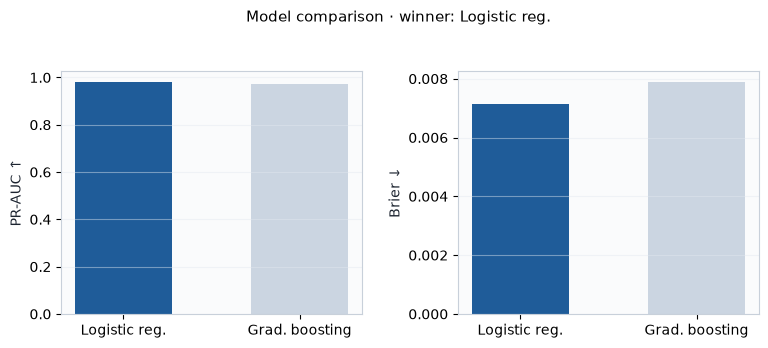

In [10]:
comparison = metrics["model_comparison"]
selected = metrics["selected_model"]
labels = {"logreg": "Logistic regression", "hgb": "Hist gradient boosting"}
print(f"Selected for serving: {labels[selected]}")

fig = plot_model_comparison(comparison, selected)
plt.show()


On the test split I care about **PR-AUC** (ranking quality when positives are rare) and **Brier score** (calibrated probabilities).


Accuracy @0.5: 0.989  ·  PR-AUC: 0.979  ·  Brier: 0.0071  ·  Test rows: 360


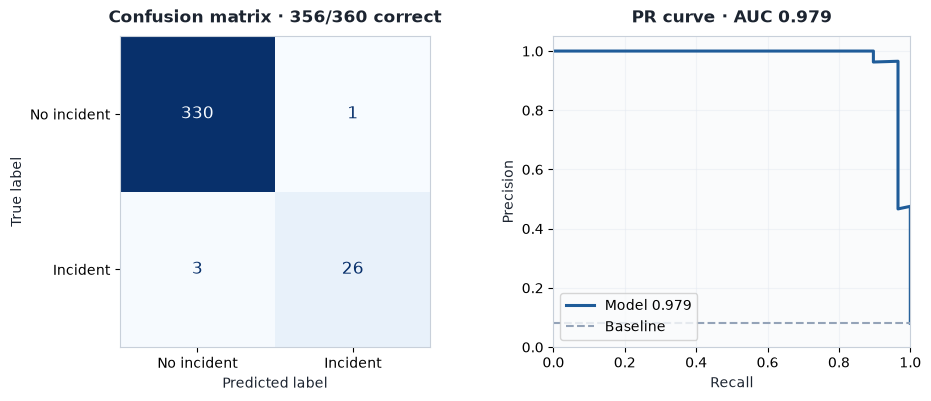

y_true,y_prob,y_pred@0.5
0,0.001000,0
0,0.001000,0
0,0.006000,0
0,0.000000,0
0,0.002000,0
0,0.020000,0
0,0.000000,0
0,0.001000,0
0,0.007000,0
0,0.001000,0


In [11]:
holdout = holdout_evaluation(training_rows, ARTIFACT_DIR)
print(
    f"Accuracy @0.5: {holdout['accuracy']:.3f}  ·  "
    f"PR-AUC: {holdout['pr_auc']:.3f}  ·  "
    f"Brier: {holdout['brier_score']:.4f}  ·  "
    f"Test rows: {holdout['test_rows']}"
)

fig = plot_holdout_panels(holdout)
plt.show()

display(
    style_predictions_table(
        pd.DataFrame(
            {
                "y_true": holdout["y_true"][:12],
                "y_prob": [round(p, 3) for p in holdout["y_prob"][:12]],
                "y_pred@0.5": holdout["y_pred"][:12],
            }
        )
    )
)


---
# Phase B: live inference

I generate five demo streams (24 hourly readings each, plus duplicates/door events where the story needs them). Each stream tests a different real-world failure mode:

| Shipment | What I'm proving |
|----------|------------------|
| `s-demo-stable` | Steady temps + duplicate redeliveries → low risk, idempotent ingest |
| `s-demo-warming` | Rising slope → risk climbs before incident |
| `s-demo-correction` | Late revision must **not** rewrite a score already issued |
| `s-demo-door` | Door-open events + warming → `door_open_seen` drives risk up |
| `s-demo-delayed` | Only `received_at` counts: delayed packets aren't known until they arrive |

Set `DEMO_SEED` in the next cell to control the stream, then pick one shipment, load the frozen model, ingest in delivery order, and score at decision times.


In [12]:
DEMO_SEED = 8000  # change seed to regenerate a different demo stream (e.g. 7777)

manifest = write_walkthrough_dataset(WALKTHROUGH_DIR, DEMO_SEED)
print(
    f"✓ Generated {manifest['shipment_count']} demo shipments "
    f"(seed {manifest['seed']}, {manifest['events']} events, "
    f"{manifest.get('stream_hours', 24)}h streams) → optional/data/walkthrough/"
)

shipments_df = pd.DataFrame(manifest["shipments"])[
    ["shipment_id", "use_case", "talk_about", "has_incident", "events"]
]
display(style_manifest_table(shipments_df))


✓ Generated 5 demo shipments (seed 8000, 144 events, 24h streams) → optional/data/walkthrough/


shipment_id,use_case,talk_about,has_incident,events
s-demo-stable,Stable cold chain,Steady 3-4 C with duplicate deliveries. Repeats are ignored by event_id and revision.,False,28
s-demo-warming,Gradual warming,Temperature drifts up. Incident within 6 hours at the 14:00 score.,True,26
s-demo-correction,Late correction,Correction arrives at hour 22 but score at hour 8 must stay the same.,True,28
s-demo-door,Door open event,5 door-open events and warming. door_open_seen raises the score.,True,32
s-demo-delayed,Delayed telemetry,Readings from hour 15+ arrive 3 hours late. Only received_at counts when scoring.,True,30


In [13]:
SHIPMENT = "s-demo-stable" 
meta = next(r for r in walkthrough_shipment_options(WALKTHROUGH_DIR) if r["shipment_id"] == SHIPMENT)
print(f"Use case: {meta['use_case']}")
print(f"Why it matters: {meta['talk_about']}")


Use case: Stable cold chain
Why it matters: Steady 3-4 C with duplicate deliveries. Repeats are ignored by event_id and revision.


s-demo-stable: 28 events ingested for Phase B


,#,event_id,kind,value,device_time,received_at,revision,flags,delay_min
0,0,s-demo-stable-temp-00,temperature_c,3.438000,2026-03-15 00:00,2026-03-15 00:48,1,normal,48.000000
1,1,s-demo-stable-temp-02,temperature_c,3.417000,2026-03-15 02:00,2026-03-15 02:18,1,normal,18.000000
2,2,s-demo-stable-temp-02,temperature_c,3.417000,2026-03-15 02:00,2026-03-15 02:18,1,duplicate,18.000000
3,3,s-demo-stable-temp-01,temperature_c,3.467000,2026-03-15 01:00,2026-03-15 02:30,1,delayed,90.000000
4,4,s-demo-stable-temp-03,temperature_c,3.686000,2026-03-15 03:00,2026-03-15 03:01,1,normal,1.000000
5,5,s-demo-stable-temp-04,temperature_c,3.392000,2026-03-15 04:00,2026-03-15 04:00,1,normal,0.000000
6,6,s-demo-stable-temp-05,temperature_c,3.388000,2026-03-15 05:00,2026-03-15 05:01,1,normal,1.000000
7,7,s-demo-stable-temp-06,temperature_c,3.741000,2026-03-15 06:00,2026-03-15 06:48,1,normal,48.000000
8,8,s-demo-stable-temp-07,temperature_c,3.620000,2026-03-15 07:00,2026-03-15 07:11,1,normal,11.000000
9,9,s-demo-stable-temp-08,temperature_c,3.906000,2026-03-15 08:00,2026-03-15 08:48,1,normal,48.000000


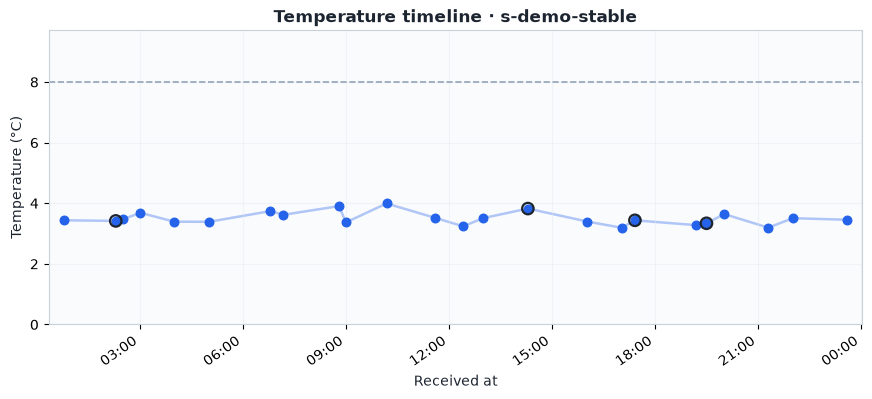

In [14]:
new_events = load_events(WALKTHROUGH_DIR)
new_labels = load_labels(WALKTHROUGH_DIR)
new_decisions = load_decision_times(WALKTHROUGH_DIR)
incident_at = incident_time_for_shipment(new_labels, SHIPMENT)
shipment_events = events_for_shipment(new_events, SHIPMENT)

print(f"{SHIPMENT}: {len(shipment_events)} events ingested for Phase B")

event_df = events_to_display_df(shipment_events)
display(style_events_table(event_df))

fig = plot_shipment_timeline(shipment_events, SHIPMENT)
plt.show()


In [15]:
# Recreate on each run so regenerating the walkthrough (or re-loading events)
# cannot trip "conflicting redelivery" from a stale engine in this kernel.
engine = RiskEngine(ARTIFACT_DIR, max_shipments=10)
print("Loaded model, inference only, no retrain.")


Loaded model, inference only, no retrain.


In [16]:
engine = RiskEngine(ARTIFACT_DIR, max_shipments=10)
for event in shipment_events:
    engine.ingest(event)

print(f"Ingested {len(shipment_events)} events for {SHIPMENT}")
print(json.dumps(dict(engine.stats()), indent=2))


Ingested 28 events for s-demo-stable
{
  "active_shipments": 1,
  "ingest_count": 24,
  "max_shipments": 10,
  "model_version": "logreg-v1",
  "reload_count": 0,
  "score_count": 0,
  "seen_deliveries": 24
}


In [17]:
rows = []
for sid, as_of in new_decisions:
    if sid != SHIPMENT:
        continue
    pred = engine.score(SHIPMENT, as_of)
    rows.append(
        {
            "as_of": as_of.strftime("%Y-%m-%d %H:%M"),
            "probability": round(pred.probability, 3),
            "probability_pct": f"{pred.probability:.1%}",
            "reasons": ", ".join(pred.reasons) or "(none)",
            "true_label_next_6h": label_in_next_6h(as_of, incident_at),
        }
    )

pred_df = pd.DataFrame(rows)
display(style_predictions_table(pred_df))


as_of,probability,probability_pct,reasons,true_label_next_6h
2026-03-15 08:00,0.000000,0.0%,(none),0
2026-03-15 14:00,0.000000,0.0%,(none),0
2026-03-15 20:00,0.000000,0.0%,(none),0


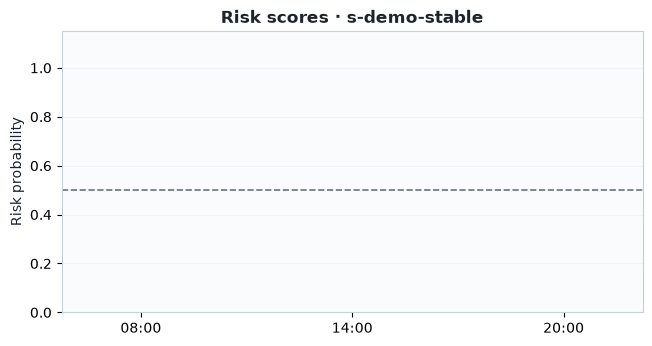

In [18]:
fig = plot_risk_scores(pred_df, SHIPMENT)
plt.show()


## Late correction: the invariant I care about

This always runs on `s-demo-correction` (independent of the shipment picked above).

Business rule: if I scored at 08:00 with what I knew then, a correction that **arrives later** must not change that historical prediction.


same_prediction: True  ·  before=0.0%  after=0.0%


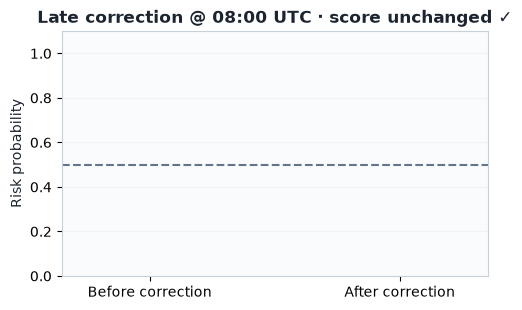

In [19]:
before, after, as_of_past = demo_late_correction(ARTIFACT_DIR, WALKTHROUGH_DIR)

same = before.to_wire() == after.to_wire()
print(f"same_prediction: {same}  ·  before={before.probability:.1%}  after={after.probability:.1%}")

fig = plot_correction_before_after(
    before.probability,
    after.probability,
    as_of_label=as_of_past.strftime("%H:%M UTC"),
)
plt.show()



---
# Key takeaways

**Point-in-time correctness**
- Features and scoring use `received_at <= decision_time`, not `device_time`.
- Corrections store all revisions; past `as_of` scores stay frozen.

**Training vs live**
- Train once offline → `model.joblib`. Live path loads and predicts; ingest never retrains.
- Evaluation splits by **shipment** to mimic deploying on new routes.

**Telemetry noise I designed for**
- Duplicate `(event_id, revision)` deliveries are ignored; ingest is idempotent.
- Door opens, warming slope, and delayed packets are separate risk signals in the feature vector.

**What I'd tell ops**
- High score + `door_open_seen` or rising max temp → investigate before product spoils.
- A late calibration fix updates **future** scores only, not alerts already sent.

Full policy notes: `DECISIONS.md` · Regression coverage: `pytest -v` (23 tests)
